In [1]:
# 基础环境与复现实验设置
import math
import random
from collections import Counter
from contextlib import contextmanager

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.nn.utils.rnn import (
    pack_padded_sequence,
    pad_packed_sequence,
)
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.13.0+cpu
Device: cpu


## 1. 总览：一条文本如何变成类别分数

设：

- 批大小为 \(B\)
- 序列最大长度为 \(L\)
- 词表大小为 \(V\)
- 词向量维度为 \(D\)
- LSTM 单方向隐藏维度为 \(H\)
- 类别数为 \(C\)

数据流如下：

```text
input_ids              Embedding              BiLSTM
(B, L)  ───────────▶  (B, L, D)  ─────────▶ (B, L, 2H)
                                                │
                                                ▼
                                       attention score
                                           (B, L)
                                                │ mask + softmax
                                                ▼
                                      attention weights
                                           (B, L)
                                                │ weighted sum
                                                ▼
                                           context
                                           (B, 2H)
                                                │ Linear
                                                ▼
                                            logits
                                            (B, C)
```

最关键的维度变化只有两次：

1. `Embedding` 为每个 token 增加一个向量维度：`(B, L) → (B, L, D)`。
2. 注意力池化消去序列维度：`(B, L, 2H) → (B, 2H)`。


## 2. 构造一个可控的微型文本数据集

为保证 Notebook 离线可运行，这里使用空格分词的英文短句。真实中文项目可替换为：

- 字级切分；
- `jieba` 等分词器；
- BERT/Tokenizer 产生的 subword ID。

本节只关注 **ID、padding、mask 和模型连接**，分词算法不是重点。


In [3]:
samples = [
    ("this movie is excellent", 1),
    ("a really good film", 1),
    ("the story is touching", 1),
    ("actors did a great job", 1),
    ("i love this movie", 1),
    ("wonderful plot and music", 1),
    ("very enjoyable and warm", 1),
    ("the ending is satisfying", 1),
    ("this film is boring", 0),
    ("a really bad movie", 0),
    ("the story is terrible", 0),
    ("actors did a poor job", 0),
    ("i hate this film", 0),
    ("awful plot and music", 0),
    ("very dull and slow", 0),
    ("the ending is disappointing", 0),
]

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_IDX = 0
UNK_IDX = 1

def tokenize(text):
    return text.lower().split()

counter = Counter()
for text, _ in samples:
    counter.update(tokenize(text))

itos = [PAD_TOKEN, UNK_TOKEN] + sorted(counter)
stoi = {token: idx for idx, token in enumerate(itos)}

def encode(text):
    return [stoi.get(token, UNK_IDX) for token in tokenize(text)]

print("vocab_size =", len(itos))
print("前 15 个词表项：", list(enumerate(itos[:15])))
print("示例编码：", tokenize(samples[0][0]), "->", encode(samples[0][0]))


vocab_size = 37
前 15 个词表项： [(0, '<pad>'), (1, '<unk>'), (2, 'a'), (3, 'actors'), (4, 'and'), (5, 'awful'), (6, 'bad'), (7, 'boring'), (8, 'did'), (9, 'disappointing'), (10, 'dull'), (11, 'ending'), (12, 'enjoyable'), (13, 'excellent'), (14, 'film')]
示例编码： ['this', 'movie', 'is', 'excellent'] -> [32, 22, 19, 13]


In [4]:
def pad_batch(sequences, pad_value=PAD_IDX):
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    max_len = int(lengths.max())
    input_ids = torch.full((len(sequences), max_len), pad_value, dtype=torch.long)
    for row, seq in enumerate(sequences):
        input_ids[row, :len(seq)] = torch.tensor(seq, dtype=torch.long)
    attention_mask = input_ids.ne(pad_value)  # True 表示有效 token
    return input_ids, attention_mask, lengths

demo_texts = [
    "this movie is excellent",
    "a good film",
]
demo_sequences = [encode(text) for text in demo_texts]
demo_ids, demo_mask, demo_lengths = pad_batch(demo_sequences)

print("input_ids:")
print(demo_ids)
print("\nattention_mask:")
print(demo_mask)
print("\nlengths:", demo_lengths.tolist())
print("\nshape:", tuple(demo_ids.shape))


input_ids:
tensor([[32, 22, 19, 13],
        [ 2, 15, 14,  0]])

attention_mask:
tensor([[ True,  True,  True,  True],
        [ True,  True,  True, False]])

lengths: [4, 3]

shape: (2, 4)


### 2.1 `input_ids` 与 `attention_mask` 的职责不同

- `input_ids[b, t]`：第 \(b\) 个样本、第 \(t\) 个位置对应的词表索引。
- `attention_mask[b, t]`：该位置是否为真实 token。`True/1` 表示有效，`False/0` 表示 padding。

`padding_idx=0` 会让 `Embedding` 的第 0 行保持为零向量，但这并不自动告诉 LSTM “不要处理该位置”。因此后面还需要：

1. 用序列长度进行 packing，使 LSTM 跳过 padding；
2. 用 mask 排除注意力 softmax 中的 padding 位置。
## 3. Embedding：从离散 ID 到连续向量

`nn.Embedding(V, D)` 本质上是一张可训练查找表：

\[
\mathbf{E}\in \mathbb{R}^{V\times D}
\]

输入整数 ID 后，PyTorch 取出对应行：

\[
\mathbf{X}_{b,t}=\mathbf{E}[\text{input\_ids}_{b,t}]
\]

因此：

- 输入：`LongTensor`，shape 为 `(B, L)`；
- 输出：浮点 Tensor，shape 为 `(B, L, D)`；
- 参数量：`V × D`。


In [5]:

embed_dim = 8
embedding = nn.Embedding(
    num_embeddings=len(itos),
    embedding_dim=embed_dim,
    padding_idx=PAD_IDX,
)

embedded = embedding(demo_ids)
print("input_ids shape :", tuple(demo_ids.shape))
print("embedded shape  :", tuple(embedded.shape))
print("Embedding 参数量:", embedding.weight.numel())
print("padding 向量     :", embedding.weight[PAD_IDX].detach())


input_ids shape : (2, 4)
embedded shape  : (2, 4, 8)
Embedding 参数量: 296
padding 向量     : tensor([0., 0., 0., 0., 0., 0., 0., 0.])



## 4. 双向 LSTM：为每个位置融合左右上下文

单向 LSTM 在位置 \(t\) 只能使用一侧历史；双向 LSTM 同时计算：

\[
\overrightarrow{\mathbf{h}}_t
\quad\text{和}\quad
\overleftarrow{\mathbf{h}}_t
\]

然后拼接：

\[
\mathbf{h}_t=
[\overrightarrow{\mathbf{h}}_t;\overleftarrow{\mathbf{h}}_t]
\in\mathbb{R}^{2H}
\]

所以当 `hidden_size=H` 且 `bidirectional=True` 时，序列输出为 `(B, L, 2H)`。

### 为什么使用 packing？

如果把 padding 直接送入双向 LSTM：

- 前向方向通常在有效 token 之后才遇到 padding；
- 反向方向却会先读 padding，再读有效 token；
- 因此只在最终注意力阶段屏蔽 padding，并不能完全消除 padding 对反向状态的影响。

`pack_padded_sequence` 会让循环网络只处理有效长度。


In [6]:

hidden_dim = 6
lstm = nn.LSTM(
    input_size=embed_dim,
    hidden_size=hidden_dim,
    batch_first=True,
    bidirectional=True,
)

packed = pack_padded_sequence(
    embedded,
    lengths=demo_lengths.cpu(),
    batch_first=True,
    enforce_sorted=False,
)
packed_output, (h_n, c_n) = lstm(packed)
sequence_output, unpacked_lengths = pad_packed_sequence(
    packed_output,
    batch_first=True,
    total_length=demo_ids.size(1),
)

print("embedded shape       :", tuple(embedded.shape))
print("sequence_output shape:", tuple(sequence_output.shape))
print("h_n shape            :", tuple(h_n.shape))
print("unpacked lengths     :", unpacked_lengths.tolist())

assert sequence_output.shape[-1] == hidden_dim * 2


embedded shape       : (2, 4, 8)
sequence_output shape: (2, 4, 12)
h_n shape            : (2, 2, 6)
unpacked lengths     : [4, 3]



## 5. Masked Attention Pooling：学习“哪些位置更重要”

对每个位置的 BiLSTM 输出 \(\mathbf{h}_t\) 计算一个标量分数：

\[
e_t=\mathbf{w}^{\top}\mathbf{h}_t+b
\]

在有效 token 上做 softmax：

\[
\alpha_t=
\frac{\exp(e_t)}
{\sum_{j\in\text{valid}}\exp(e_j)}
\]

最后加权求和：

\[
\mathbf{c}=\sum_{t=1}^{L}\alpha_t\mathbf{h}_t
\]

其中：

- `scores`：`(B, L)`
- `weights`：`(B, L)`，每条样本有效位置之和为 1
- `context`：`(B, 2H)`

### mask 为什么在 softmax 之前使用？

若先 softmax 再把 padding 权重置零，剩余有效 token 的权重之和会小于 1。正确做法是先把 padding 分数设为极小值，再执行 softmax。


In [7]:

class MaskedAttentionPooling(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.score = nn.Linear(input_dim, 1)

    def forward(self, sequence_output, attention_mask):
        # sequence_output: (B, L, F)
        # attention_mask : (B, L), True 表示有效位置
        if not attention_mask.any(dim=1).all():
            raise ValueError("每条序列至少需要一个有效 token。")

        scores = self.score(sequence_output).squeeze(-1)  # (B, L)

        # 用当前 dtype 的最小有限值屏蔽 padding。
        min_value = torch.finfo(scores.dtype).min
        masked_scores = scores.masked_fill(~attention_mask.bool(), min_value)

        weights = torch.softmax(masked_scores, dim=1)  # (B, L)
        context = torch.bmm(
            weights.unsqueeze(1), sequence_output
        ).squeeze(1)  # (B, F)

        return context, weights, scores

attention_pool = MaskedAttentionPooling(input_dim=hidden_dim * 2)
context, weights, raw_scores = attention_pool(sequence_output, demo_mask)

print("sequence_output:", tuple(sequence_output.shape))
print("raw_scores     :", tuple(raw_scores.shape))
print("weights        :", tuple(weights.shape))
print("context        :", tuple(context.shape))
print("每条样本权重和 :", weights.sum(dim=1).detach())
print("padding 位置权重:", weights.masked_select(~demo_mask).detach())


sequence_output: (2, 4, 12)
raw_scores     : (2, 4)
weights        : (2, 4)
context        : (2, 12)
每条样本权重和 : tensor([1., 1.])
padding 位置权重: tensor([0.])



## 6. 完整模型：Embedding → Packed BiLSTM → Attention → Classifier

为了便于调试，`forward` 支持 `return_details=True`，同时返回中间张量。科研代码中建议保留这种“可观测接口”，而不是只能得到最终 logits。


In [8]:

class BiLSTMAttentionClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=24,
        hidden_dim=16,
        num_classes=2,
        num_layers=1,
        dropout=0.2,
        padding_idx=PAD_IDX,
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=padding_idx,
        )
        self.embedding_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.attention_pool = MaskedAttentionPooling(hidden_dim * 2)
        self.output_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask, return_details=False):
        lengths = attention_mask.sum(dim=1).to(torch.long)

        embedded = self.embedding_dropout(self.embedding(input_ids))

        packed = pack_padded_sequence(
            embedded,
            lengths=lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_output, _ = self.lstm(packed)
        sequence_output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=input_ids.size(1),
        )

        context, attention_weights, attention_scores = self.attention_pool(
            sequence_output,
            attention_mask,
        )
        logits = self.classifier(self.output_dropout(context))

        if return_details:
            return {
                "logits": logits,
                "embedded": embedded,
                "sequence_output": sequence_output,
                "attention_scores": attention_scores,
                "attention_weights": attention_weights,
                "context": context,
            }
        return logits

text_model = BiLSTMAttentionClassifier(vocab_size=len(itos)).to(device)
print(text_model)
print("可训练参数量:", sum(p.numel() for p in text_model.parameters() if p.requires_grad))


BiLSTMAttentionClassifier(
  (embedding): Embedding(37, 24, padding_idx=0)
  (embedding_dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(24, 16, batch_first=True, bidirectional=True)
  (attention_pool): MaskedAttentionPooling(
    (score): Linear(in_features=32, out_features=1, bias=True)
  )
  (output_dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)
可训练参数量: 6363


In [9]:

text_model.eval()
with torch.no_grad():
    details = text_model(
        demo_ids.to(device),
        demo_mask.to(device),
        return_details=True,
    )

shape_audit = {
    "input_ids": tuple(demo_ids.shape),
    "attention_mask": tuple(demo_mask.shape),
    "embedded": tuple(details["embedded"].shape),
    "sequence_output": tuple(details["sequence_output"].shape),
    "attention_scores": tuple(details["attention_scores"].shape),
    "attention_weights": tuple(details["attention_weights"].shape),
    "context": tuple(details["context"].shape),
    "logits": tuple(details["logits"].shape),
}
for name, shape in shape_audit.items():
    print(f"{name:18s} -> {shape}")

valid_sums = (
    details["attention_weights"]
    * demo_mask.to(device)
).sum(dim=1)
pad_weights = details["attention_weights"].masked_select(~demo_mask.to(device))

assert torch.allclose(valid_sums, torch.ones_like(valid_sums), atol=1e-6)
assert pad_weights.numel() == 0 or float(pad_weights.max()) < 1e-6
print("\nShape 与 mask 检查通过。")


input_ids          -> (2, 4)
attention_mask     -> (2, 4)
embedded           -> (2, 4, 24)
sequence_output    -> (2, 4, 32)
attention_scores   -> (2, 4)
attention_weights  -> (2, 4)
context            -> (2, 32)
logits             -> (2, 2)

Shape 与 mask 检查通过。



### 6.1 逐层 shape 对照表

| 张量 | 含义 | Shape |
|---|---|---|
| `input_ids` | token 索引 | `(B, L)` |
| `attention_mask` | 有效位置 | `(B, L)` |
| `embedded` | token 向量 | `(B, L, D)` |
| `sequence_output` | 双向上下文表示 | `(B, L, 2H)` |
| `attention_scores` | 未归一化重要性 | `(B, L)` |
| `attention_weights` | 归一化权重 | `(B, L)` |
| `context` | 句子级表示 | `(B, 2H)` |
| `logits` | 类别分数 | `(B, C)` |

注意：`logits` 不是概率。多分类通常用 `CrossEntropyLoss`，它内部会处理 `log_softmax`。

## 7. 微型训练闭环：让注意力权重变得可解释

下面在 16 条短句上训练。数据极小，结果仅用于观察代码流程；不能据此评价 BiLSTM 的真实泛化能力。


In [10]:

class TinyTextDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        text, label = self.records[idx]
        return {
            "text": text,
            "token_ids": encode(text),
            "label": label,
        }

def collate_text_batch(batch):
    sequences = [item["token_ids"] for item in batch]
    input_ids, attention_mask, lengths = pad_batch(sequences)
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    texts = [item["text"] for item in batch]
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "lengths": lengths,
        "labels": labels,
        "texts": texts,
    }

dataset = TinyTextDataset(samples)
train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_text_batch,
    generator=torch.Generator().manual_seed(SEED),
)

batch = next(iter(train_loader))
print("batch input_ids:", tuple(batch["input_ids"].shape))
print("batch labels   :", tuple(batch["labels"].shape))
print("示例文本       :", batch["texts"][0])


batch input_ids: (8, 4)
batch labels   : (8,)
示例文本       : i hate this film


In [11]:

train_model = BiLSTMAttentionClassifier(
    vocab_size=len(itos),
    embed_dim=24,
    hidden_dim=16,
    num_classes=2,
    dropout=0.1,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(train_model.parameters(), lr=0.01)

history = []
num_epochs = 30

for epoch in range(1, num_epochs + 1):
    train_model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = train_model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(train_model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / total
    epoch_acc = correct / total
    history.append((epoch_loss, epoch_acc))

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | loss={epoch_loss:.4f} | acc={epoch_acc:.3f}")


Epoch 01 | loss=0.7026 | acc=0.500
Epoch 05 | loss=0.6152 | acc=0.875
Epoch 10 | loss=0.3641 | acc=1.000
Epoch 15 | loss=0.0879 | acc=1.000
Epoch 20 | loss=0.0150 | acc=1.000
Epoch 25 | loss=0.0022 | acc=1.000
Epoch 30 | loss=0.0016 | acc=1.000


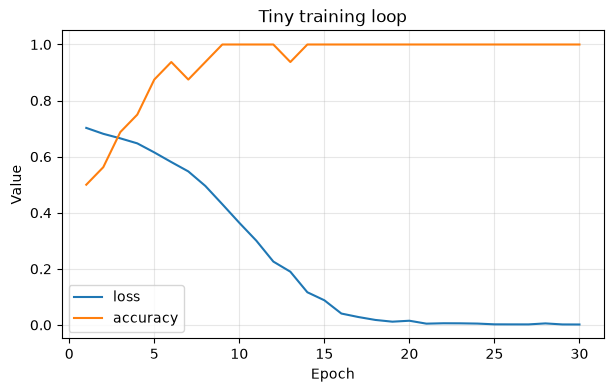

In [12]:

loss_values = [item[0] for item in history]
acc_values = [item[1] for item in history]

plt.figure(figsize=(7, 4))
plt.plot(range(1, num_epochs + 1), loss_values, label="loss")
plt.plot(range(1, num_epochs + 1), acc_values, label="accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Tiny training loop")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


文本: this movie is really excellent
预测类别: 1 （1=positive, 0=negative）
概率: [7.2228097e-05 9.9992776e-01]

Token 注意力：
  this           0.3636
  movie          0.1968
  is             0.1921
  really         0.1192
  excellent      0.1284


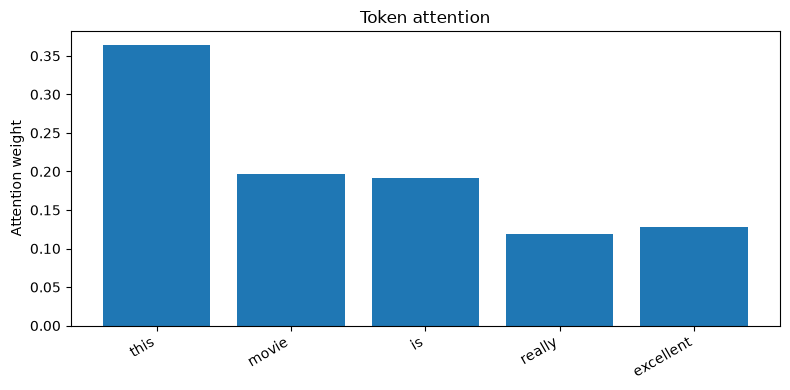

In [13]:

def prepare_single_text(text):
    ids, mask, _ = pad_batch([encode(text)])
    return ids.to(device), mask.to(device)

def inspect_text(model, text):
    model.eval()
    input_ids, mask = prepare_single_text(text)
    with torch.no_grad():
        result = model(input_ids, mask, return_details=True)
        probabilities = torch.softmax(result["logits"], dim=1)[0]
        weights = result["attention_weights"][0]

    tokens = tokenize(text)
    weights = weights[:len(tokens)].cpu().numpy()
    prediction = int(probabilities.argmax())

    print("文本:", text)
    print("预测类别:", prediction, "（1=positive, 0=negative）")
    print("概率:", probabilities.cpu().numpy())
    print("\nToken 注意力：")
    for token, weight in zip(tokens, weights):
        print(f"  {token:14s} {weight:.4f}")

    plt.figure(figsize=(8, 4))
    plt.bar(range(len(tokens)), weights)
    plt.xticks(range(len(tokens)), tokens, rotation=30, ha="right")
    plt.ylabel("Attention weight")
    plt.title("Token attention")
    plt.tight_layout()
    plt.show()

inspect_text(train_model, "this movie is really excellent")



### 7.1 如何正确解释注意力权重

注意力权重可以帮助调试，但不应自动等同于“严格因果解释”。

可做的事情：

- 检查模型是否把大量权重分给 padding；
- 检查模型是否关注任务相关词；
- 比较同一句子在不同 checkpoint 下的变化；
- 发现数据偏见或快捷特征。

不能直接断言：

- 权重最高的 token 一定是预测的唯一原因；
- 删除该 token 后预测一定按比例变化；
- 注意力图等价于可靠的模型解释。

更严格的分析可结合遮挡实验、梯度方法或反事实样本。



# 第二部分：用 Forward Hook 读取 CNN 中间层特征

## 8. Forward hook 的执行时机

对模块 `layer` 注册：

```python
handle = layer.register_forward_hook(hook_fn)
```

当模型执行到该模块并完成 `output = layer(input)` 后，PyTorch 自动调用：

```python
hook_fn(module, inputs, output)
```

三个参数：

- `module`：当前被观察的层对象；
- `inputs`：传给该层的输入，通常是 tuple；
- `output`：该层的输出 Tensor，或由多个 Tensor 构成的结构。

hook 不需要修改模型的 `forward`，适合：

- 特征图可视化；
- 中间表示统计；
- 调试 shape；
- 提取用于下游任务的 frozen features；
- 检查某层是否真正执行。



## 9. 先从一个可控的 TinyCNN 开始

输入图像 shape 为 `(B, 3, H, W)`。卷积层输出 `(B, C, H', W')`：

- `B`：批大小；
- `C`：通道数，每个通道可理解为一种学习到的响应模式；
- `H', W'`：空间分辨率。

我们生成一张包含渐变、方块和圆形区域的合成 RGB 图像，避免依赖外部文件。


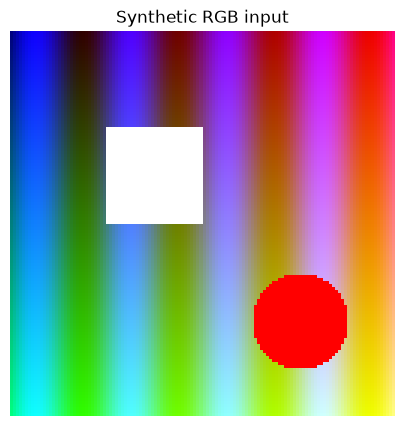

input_tensor: (1, 3, 128, 128)


In [14]:

def make_synthetic_image(size=128):
    y = torch.linspace(0, 1, size).view(size, 1).expand(size, size)
    x = torch.linspace(0, 1, size).view(1, size).expand(size, size)

    red = x.clone()
    green = y.clone()
    blue = 0.5 * (torch.sin(8 * math.pi * x) + 1.0)

    image = torch.stack([red, green, blue], dim=0)

    # 中央方块
    image[:, size//4:size//2, size//4:size//2] = 1.0

    # 圆形区域
    yy, xx = torch.meshgrid(
        torch.arange(size),
        torch.arange(size),
        indexing="ij",
    )
    circle = (xx - 3 * size / 4) ** 2 + (yy - 3 * size / 4) ** 2 < (size / 8) ** 2
    image[0, circle] = 1.0
    image[1, circle] = 0.0
    image[2, circle] = 0.0

    return image.clamp(0, 1)

synthetic_image = make_synthetic_image()
input_tensor = synthetic_image.unsqueeze(0).to(device)

plt.figure(figsize=(5, 5))
plt.imshow(synthetic_image.permute(1, 2, 0).numpy())
plt.title("Synthetic RGB input")
plt.axis("off")
plt.show()

print("input_tensor:", tuple(input_tensor.shape))


In [15]:

class TinyCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(16, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

cnn = TinyCNN().to(device).eval()
print(cnn)


TinyCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (classifier): Linear(in_features=16, out_features=3, bias=True)
)



### 9.1 找到要 hook 的层

`named_modules()` 会递归列出模型中的模块名称。实际项目中不要凭感觉猜层名，先打印结构，再确定目标层。


In [17]:

for name, module in cnn.named_modules():
    if name:
        print(f"{name:15s} -> {module.__class__.__name__}")


features        -> Sequential
features.0      -> Conv2d
features.1      -> ReLU
features.2      -> MaxPool2d
features.3      -> Conv2d
features.4      -> ReLU
features.5      -> MaxPool2d
pool            -> AdaptiveAvgPool2d
classifier      -> Linear


In [18]:

captured = {}

def conv2_hook(module, inputs, output):
    # detach: 切断 autograd 图；cpu: 避免长期占用 GPU 显存
    captured["features.3"] = output.detach().cpu()

handle = cnn.features[3].register_forward_hook(conv2_hook)

with torch.no_grad():
    logits = cnn(input_tensor)

print("model logits:", tuple(logits.shape))
print("hook output :", tuple(captured["features.3"].shape))

# hook 在移除前，每次 forward 都会触发
handle.remove()


model logits: (1, 3)
hook output : (1, 16, 64, 64)



## 10. 把多通道特征图拼成一张图

为了避免创建大量独立图表，下面将前若干通道分别归一化，再拼成一个网格。每个小块对应一个 channel。

> 注意：不同 channel 单独归一化便于观察纹理，但会丢失通道间绝对幅值差异。做定量比较时应保留原始数值。


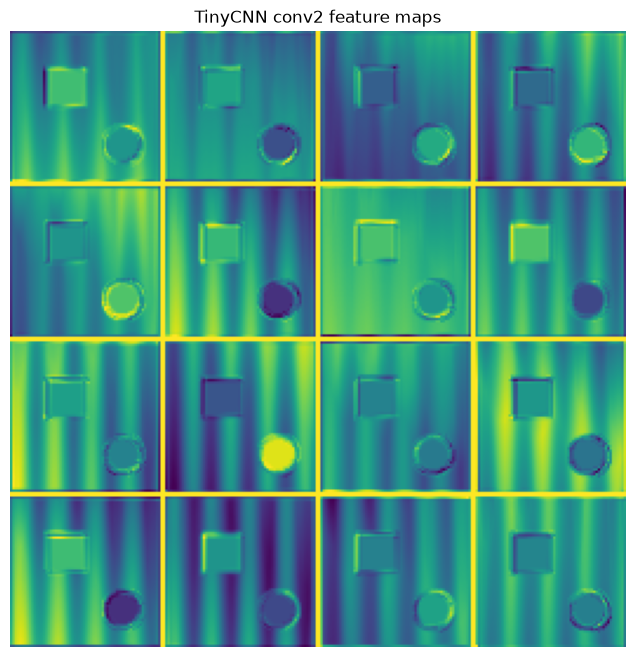

In [19]:

def make_feature_grid(feature_map, max_channels=16, columns=4, padding=2):
    # feature_map: (C, H, W)
    fmap = feature_map[:max_channels].float()
    channels, height, width = fmap.shape

    # 每个通道独立归一化到 [0, 1]
    flat = fmap.flatten(1)
    mins = flat.min(dim=1).values.view(-1, 1, 1)
    maxs = flat.max(dim=1).values.view(-1, 1, 1)
    fmap = (fmap - mins) / (maxs - mins + 1e-8)

    rows = math.ceil(channels / columns)
    grid_h = rows * height + (rows - 1) * padding
    grid_w = columns * width + (columns - 1) * padding
    grid = torch.ones(grid_h, grid_w)

    for idx in range(channels):
        row = idx // columns
        col = idx % columns
        y0 = row * (height + padding)
        x0 = col * (width + padding)
        grid[y0:y0 + height, x0:x0 + width] = fmap[idx]

    return grid

tiny_fmap = captured["features.3"][0]
tiny_grid = make_feature_grid(tiny_fmap, max_channels=16)

plt.figure(figsize=(8, 8))
plt.imshow(tiny_grid.numpy())
plt.title("TinyCNN conv2 feature maps")
plt.axis("off")
plt.show()



## 11. 可复用的多层特征捕获器

常见错误是：

- 在循环中注册很多 hook，却没有保存 handle；
- 每次实验重复注册，导致同一层回调执行多次；
- 直接保存带计算图的 GPU Tensor，引发显存持续增长；
- hook 名称闭包写错，所有输出被存到同一个 key。

下面的类统一管理注册、存储与清理。


In [20]:

class ForwardFeatureCapture:
    def __init__(self, model, layer_names, move_to_cpu=True):
        self.model = model
        self.layer_names = list(layer_names)
        self.move_to_cpu = move_to_cpu
        self.features = {}
        self.handles = []

        modules = dict(model.named_modules())
        missing = [name for name in self.layer_names if name not in modules]
        if missing:
            raise KeyError(f"找不到层：{missing}")

        for name in self.layer_names:
            module = modules[name]
            handle = module.register_forward_hook(self._build_hook(name))
            self.handles.append(handle)

    def _build_hook(self, name):
        def hook(module, inputs, output):
            if not torch.is_tensor(output):
                raise TypeError(
                    f"层 {name} 的输出不是单个 Tensor；"
                    "请按该模块的输出结构定制 hook。"
                )
            value = output.detach()
            if self.move_to_cpu:
                value = value.cpu()
            self.features[name] = value
        return hook

    def clear(self):
        self.features.clear()

    def remove(self):
        for handle in self.handles:
            handle.remove()
        self.handles.clear()

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        self.remove()

layer_names = ["features.0", "features.3", "pool"]

with ForwardFeatureCapture(cnn, layer_names) as capture:
    with torch.no_grad():
        _ = cnn(input_tensor)
    for name, value in capture.features.items():
        print(f"{name:12s} -> {tuple(value.shape)}")

print("退出 with 后 handles 数量:", len(capture.handles))


features.0   -> (1, 8, 128, 128)
features.3   -> (1, 16, 64, 64)
pool         -> (1, 16, 1, 1)
退出 with 后 handles 数量: 0



### 11.1 只保存必要统计量以节省内存

对大模型、大 batch 或视频数据，完整保存 `(B, C, H, W)` 可能非常昂贵。若目标只是监控激活分布，可在 hook 中保存：

```python
summary[name] = {
    "shape": tuple(output.shape),
    "mean": output.detach().mean().item(),
    "std": output.detach().std().item(),
    "max": output.detach().abs().max().item(),
}
```

这比保存完整 feature map 更节省显存和内存。



## 12. 迁移到 ResNet18

原学习计划使用 ResNet50 预训练模型。为保证离线可运行，本教程默认：

- 使用 `resnet18(weights=None)`；
- 不下载 ImageNet 权重；
- 重点验证 hook 机制与 shape。

随机初始化模型的特征没有语义解释价值。真实实验中可将 `weights=None` 改为 `weights="DEFAULT"` 或对应权重枚举，并使用匹配的预处理。


In [23]:

try:
    from torchvision import models
except Exception as exc:
    models = None
    print("torchvision 不可用，跳过 ResNet 扩展：", exc)

if models is not None:
    resnet = models.resnet18(weights=None).to(device).eval()
    print("ResNet18 已创建。")
    print("可选目标层：conv1, layer1, layer2, layer3, layer4, avgpool")


ResNet18 已创建。
可选目标层：conv1, layer1, layer2, layer3, layer4, avgpool


In [24]:

if models is not None:
    resnet_layers = ["conv1", "layer1", "layer2", "layer4", "avgpool"]

    with ForwardFeatureCapture(resnet, resnet_layers) as resnet_capture:
        with torch.no_grad():
            resnet_logits = resnet(input_tensor)

        print("最终输出:", tuple(resnet_logits.shape))
        for name, value in resnet_capture.features.items():
            print(f"{name:8s} -> {tuple(value.shape)}")


最终输出: (1, 1000)
conv1    -> (1, 64, 64, 64)
layer1   -> (1, 64, 32, 32)
layer2   -> (1, 128, 16, 16)
layer4   -> (1, 512, 4, 4)
avgpool  -> (1, 512, 1, 1)



观察 ResNet shape 时，通常会看到：

- 通道数逐阶段增加；
- 空间分辨率逐阶段减小；
- `avgpool` 将空间维度压缩为 `1×1`；
- 最终全连接层将通道向量映射为类别 logits。

这与文本模型中的注意力池化具有一个共同抽象：

> 前面的编码器产生“位置级特征”，后面的池化模块将位置维度聚合成固定长度表示。

区别是：

- 文本位置是一维序列 \(L\)；
- CNN 位置是二维空间 \(H\times W\)；
- 文本注意力池化学习每个 token 的权重；
- CNN 的全局平均池化通常对空间位置做均匀平均。


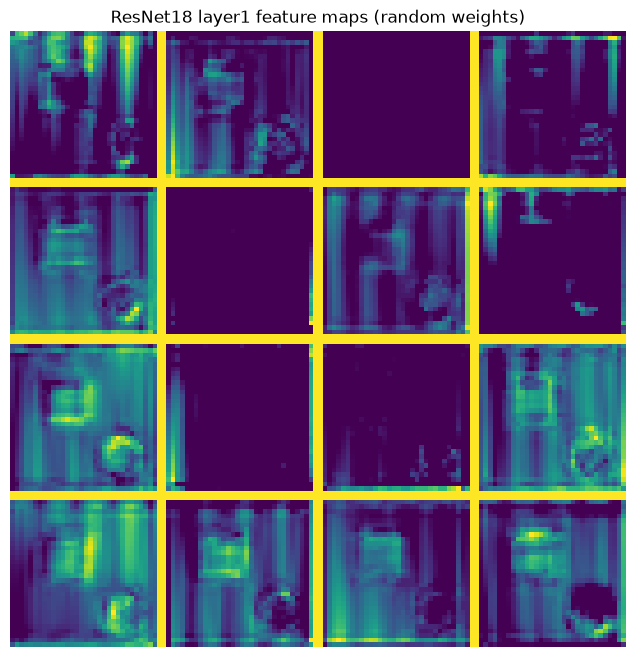

In [25]:

if models is not None:
    layer1_fmap = resnet_capture.features["layer1"][0]
    layer1_grid = make_feature_grid(layer1_fmap, max_channels=16)

    plt.figure(figsize=(8, 8))
    plt.imshow(layer1_grid.numpy())
    plt.title("ResNet18 layer1 feature maps (random weights)")
    plt.axis("off")
    plt.show()
